# Activity: Build a decision tree

## Introduction
EN: 

A decision tree model can makes predictions for a target based on multiple features. Because decision trees are used across a wide array of industries, becoming proficient in the process of building one will help you expand your skill set in a widely-applicable way.   

For this activity, you work as a consultant for an airline. The airline is interested in predicting whether a future customer would be satisfied with their services given previous customer feedback about their flight experience. The airline would like you to construct and evaluate a model that can accomplish this goal. Specifically, they are interested in knowing which features are most important to customer satisfaction.

The data for this activity includes survey responses from 129,880 customers. It includes data points such as class, flight distance, and in-flight entertainment, among others. In a previous activity, you utilized a binomial logistic regression model to help the airline better understand this data. In this activity, your goal will be to utilize a decision tree model to predict whether or not a customer will be satisfied with their flight experience. 

Because this activity uses a dataset from the industry, you will need to conduct basic EDA, data cleaning, and other manipulations to prepare the data for modeling.

In this activity, you’ll practice the following skills:

* Importing packages and loading data
* Exploring the data and completing the cleaning process
* Building a decision tree model 
* Tuning hyperparameters using `GridSearchCV`
* Evaluating a decision tree model using a confusion matrix and various other plots

ES:

Actividad: Construir un Árbol de Decisión
Introducción
Un modelo de árbol de decisión puede realizar predicciones para una variable objetivo (target) basándose en múltiples características (features). Debido a que los árboles de decisión se utilizan en una amplia variedad de industrias, volverse competente en el proceso de construcción de uno te ayudará a expandir tus habilidades de una manera muy aplicable en el mundo profesional.

Para esta actividad, trabajarás como consultor para una aerolínea. La empresa está interesada en predecir si un futuro cliente estará satisfecho con sus servicios, dadas las opiniones previas de otros clientes sobre su experiencia de vuelo. La aerolínea desea que construyas y evalúes un modelo que pueda lograr este objetivo. Específicamente, están interesados en saber cuáles características son las más importantes para la satisfacción del cliente.

Los datos para esta actividad incluyen respuestas de encuestas de 129,880 clientes. Incluyen puntos de datos como la clase de asiento, la distancia del vuelo y el entretenimiento a bordo, entre otros. En una actividad previa, utilizaste un modelo de regresión logística binomial para ayudar a la aerolínea a comprender mejor estos datos. En esta actividad, tu objetivo será utilizar un modelo de árbol de decisión para predecir si un cliente estará satisfecho o no con su experiencia de vuelo.

Debido a que esta actividad utiliza un conjunto de datos real de la industria, necesitarás realizar un Análisis Exploratorio de Datos (EDA) básico, limpieza de datos y otras manipulaciones para preparar los datos para el modelado.

En esta actividad, practicarás las siguientes habilidades:

* Importar paquetes y cargar datos.

* Explorar los datos y completar el proceso de limpieza.

* Construir un modelo de árbol de decisión.

* Ajustar hiperparámetros utilizando GridSearchCV.

Evaluar un modelo de árbol de decisión utilizando una matriz de confusión y varios otros gráficos.

## Step 1: Imports

Import relevant Python packages. Use `DecisionTreeClassifier`,` plot_tree`, and various imports from `sklearn.metrics` to build, visualize, and evaluate the model.

### Import packages

In [2]:
### YOUR CODE HERE ###

# Standard operational package imports
import pandas as pd
import numpy as np
# Important imports for modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
# Visualization package imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

### Load the dataset

`Pandas` is used to load the **Invistico_Airline.csv** dataset. The resulting pandas DataFrame is saved in a variable named `df_original`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ###

df_original = pd.read_csv("Invistico_Airline.csv")

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use a function from the pandas library to read in the csv file.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `read_csv` function and pass in the file name as a string. 

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use `pd.read_csv("insertfilenamehere")`.

</details>

### Output the first 10 rows of data

In [4]:
### YOUR CODE HERE ###
df_original.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `head()` function.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

If only five rows are output, it is because the function by default returns five rows. To change this, specify how many rows `(n = )` you want to output.

</details>

## Step 2: Data exploration, data cleaning, and model preparation

### Prepare the data

After loading the dataset, prepare the data to be suitable for decision tree classifiers. This includes: 

*   Exploring the data
*   Checking for missing values
*   Encoding the data
*   Renaming a column
*   Creating the training and testing data

### Explore the data

Check the data type of each column. Note that decision trees expect numeric data. 

In [5]:
### YOUR CODE HERE ###
#Check the data type of each column
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

EN:

### Initial Data Exploration (EDA) Findings
By running `df_original.info()`, the following key points were identified for model preparation:

* **Dataset Structure:** The dataset contains a total of 129,880 rows and 22 columns (the *Gender* column was previously removed).
* **Categorical Variables (`object` type):** There are 4 categorical columns: `satisfaction`, `Customer Type`, `Type of Travel`, and `Class`. Since scikit-learn's decision tree classifiers require numeric inputs, these variables must be encoded in the upcoming steps.
* **Missing Values:** The column `Arrival Delay in Minutes` contains 129,487 non-null values, revealing the presence of 393 missing (null) values. All other columns are complete. A cleaning process will be required to handle these nulls prior to modeling.
* **Numerical Variables:** The remaining 18 columns are correctly stored as integers (`int64`), representing customer survey features (0-5 scale), flight distances, and departure delays.

ES: 

### Hallazgos de la Exploración Inicial de Datos (EDA)
Al ejecutar `df_original.info()`, se identificaron los siguientes puntos clave para la preparación del modelo:

* **Estructura del Dataset:** El conjunto de datos contiene un total de 129,880 filas y 22 columnas (la columna *Género* fue removida previamente).
* **Variables Categóricas (Tipo `object`):** Se identificaron 4 columnas categóricas: `satisfaction`, `Customer Type`, `Type of Travel` y `Class`. Dado que los clasificadores de árboles de decisión de scikit-learn requieren datos numéricos, estas variables deberán ser codificadas (*encoding*) en los siguientes pasos.
* **Valores Faltantes:** La columna `Arrival Delay in Minutes` contiene 129,487 valores no nulos, lo que revela la presencia de 393 valores faltantes (nulos). Todas las demás columnas están completas. Se requerirá un proceso de limpieza para manejar estos nulos antes del modelado.
* **Variables Numéricas:** Las 18 columnas restantes están correctamente almacenadas como enteros (`int64`), representando características de la encuesta a clientes (escala 0-5), distancias y retrasos de salida.

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `dtypes` attribute on the DataFrame.
</details>

### Output unique values 

The `Class` column is ordinal (meaning there is an inherent order that is significant). For example, airlines typically charge more for 'Business' than 'Eco Plus' and 'Eco'. Output the unique values in the `Class` column. 

ES:

Resultados de valores únicos
La columna Class (Clase) es ordinal (lo que significa que existe un orden inherente que es significativo). Por ejemplo, las aerolíneas normalmente cobran más por 'Business' que por 'Eco Plus' y 'Eco'. Muestra los valores únicos de la columna Class.

In [6]:
### YOUR CODE HERE ###
df_original['Class'].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

<details>
  <summary><h4><strong> Hint 1 </strong></h4></summary>

Use the `unique()` function on the column `'Class'`.

</details>

### Check the counts of the predicted labels

In order to predict customer satisfaction, verify if the dataset is imbalanced. To do this, check the counts of each of the predicted labels. 

ES:
Verificar los conteos de las etiquetas a predecir
Para poder predecir la satisfacción del cliente, verifica si el conjunto de datos está desbalanceado. Para hacer esto, consulta el conteo de cada una de las etiquetas de la variable objetivo (predicted labels).

In [7]:
### YOUR CODE HERE ###

df_original['satisfaction'].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

### Análisis del Balance de Clases / Class Balance Analysis

* **Español:** La variable objetivo `satisfaction` se encuentra bien balanceada, con 71,087 clientes satisfechos y 58,793 insatisfechos. Al no existir un desbalance severo de clases, el modelo puede entrenarse de manera directa y la métrica de Accuracy (Exactitud) será un indicador confiable del rendimiento general.
* **English:** The target variable `satisfaction` is well-balanced, with 71,087 satisfied customers and 58,793 dissatisfied customers. Since there is no severe class imbalance, the model can be trained directly, and the Accuracy metric will be a reliable indicator of overall performance.

<details>
  <summary><h4><strong> Hint 1</strong> </h4></summary>

Use a function from the pandas library that returns a pandas series containing counts of unique values. 

</details>

<details>
  <summary><h4><strong> Hint 2</strong> </h4></summary>

Use the `value_counts()` function. Set the `dropna` parameter passed in to this function to `False` if you want to examine how many NaN values there are. 

</details>

**Question:** How many satisfied and dissatisfied customers were there?

EN:

**Answer:**

Based on the analysis of the target variable `satisfaction`, the distribution of customers is as follows:

* **Satisfied Customers:** 71,087
* **Dissatisfied Customers:** 58,793

**Conclusion:** The classes are remarkably well-balanced (approximately 55% vs 45%), which is ideal for training the decision tree without requiring resampling techniques.

ES:

**Respuesta:**

Basado en el análisis de la variable objetivo `satisfaction`, la distribución de los clientes es la siguiente:

* **Clientes Satisfechos (*Satisfied*):** 71,087
* **Clientes Insatisfechos (*Dissatisfied*):** 58,793

**Conclusión:** Las clases están notablemente balanceadas (aproximadamente 55% frente a 45%), lo que es ideal para entrenar el árbol de decisión sin requerir técnicas de remuestreo.

**Question:** What percentage of customers were satisfied? 

EN:

**54.73%** of the customers were satisfied.

ES: 

El **54.73%** de los clientes estuvieron satisfechos.


### Check for missing values

The sklearn decision tree implementation does not support missing values. Check for missing values in the rows of the data. 

Verificar valores faltantes
La implementación del árbol de decisión de sklearn no admite valores faltantes. Verifica si hay valores faltantes (nulos) en las filas de los datos.

In [8]:
### YOUR CODE HERE ###
# Verificar valores faltantes
df_original.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

<details>
  <summary><h4><strong>Hint 1</h4></summary></strong>

Use the `isnull` function and the `sum` function. 

</details>

<details>
  <summary><h4><strong> Hint 2 </strong> </h4></summary>

To get the number of rows in the data with missing values, use the `isnull` function followed by the `sum` function.

</details>

**Question:** Why is it important to check how many rows and columns there are in the dataset?

EN:

**Answer:**

Checking the dimensions of the dataset (rows and columns) is fundamental for the following analytical reasons:

1. **Assessing the Impact of Missing Data:** By knowing the total number of rows ($129,880$), we can determine that the $393$ rows with null values represent only **$0.3\%$** of the entire dataset. This allows us to safely conclude that removing these records will not affect the model's representativity or predictive power.
2. **Managing Model Complexity:** The number of columns determines how many features the decision tree will evaluate when performing node splits. Knowing this dimension helps anticipate the risk of overfitting and plan the hyperparameter tuning strategy (such as `max_depth` or `min_samples_split`).
3. **Data Loading Validation:** It ensures that the data was correctly imported from the CSV file, confirming that no records or variables were lost during the ingestion process.

ES:

**Respuesta:**

Es fundamental verificar las dimensiones del conjunto de datos (filas y columnas) por las siguientes razones analíticas:

1. **Evaluación del Impacto de los Datos Faltantes:** Al conocer el número total de filas ($129,880$), podemos determinar que las $393$ filas con valores nulos representan solo un **$0.3\%$** del total. Esto nos permite concluir con seguridad que eliminar estos registros no afectará la representatividad ni el poder predictivo del modelo.
2. **Control de la Complejidad del Modelo:** El número de columnas determina la cantidad de características (*features*) que el árbol de decisión evaluará para realizar las divisiones de los nodos (*splits*). Conocer esta dimensión ayuda a anticipar el riesgo de sobreajuste (*overfitting*) y a planificar la estrategia de ajuste de hiperparámetros (como `max_depth` o `min_samples_split`).
3. **Validación de la Carga de Datos:** Asegura que los datos se hayan importado correctamente desde el archivo CSV, confirmando que no se perdieron registros ni variables durante el proceso de lectura.

### Check the number of rows and columns in the dataset

In [9]:
### YOUR CODE HERE ###
df_original.shape

(129880, 22)

<details>
  <summary><h4><strong> Hint 1 </strong> </h4></summary>

Use the `shape` attribute on the DataFrame.

</details>

### Drop the rows with missing values

Drop the rows with missing values and save the resulting pandas DataFrame in a variable named `df_subset`.

In [14]:
### YOUR CODE HERE ###

df_subset = df_original.dropna(axis=0).copy()

<details>
  <summary><h4><strong> Hint 1 </strong> </h4></summary>

Use the `dropna` function.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Set the axis parameter passed into the `dropna` function to `0` if you want to drop rows containing missing values, or `1` if you want to drop columns containing missing values. Optionally, use reset_index to avoid a SettingWithCopy warning later in the notebook. 

</details>

### Check for missing values

Check that `df_subset` does not contain any missing values.

In [15]:
### YOUR CODE HERE ###
df_subset.isnull().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use the `isna()`function and the `sum()` function. 

</details>

<details>
  <summary><h4><strong> Hint 2</strong> </h4></summary>

To get the number of rows in the data with missing values, use the `isna()` function followed by the `sum()` function.

</details>

### Check the number of rows and columns in the dataset again

Check how many rows and columns are remaining in the dataset. You should now have 393 fewer rows of data.

In [16]:
### YOUR CODE HERE ###
df_subset.shape

(129487, 22)

### Encode the data

Four columns (`satisfaction`, `Customer Type`, `Type of Travel`, `Class`) are the pandas dtype object. Decision trees need numeric columns. Start by converting the ordinal `Class` column into numeric. 

In [17]:
### YOUR CODE HERE ###
# Crear el diccionario de mapeo / Create the mapping dictionary
class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}

# Aplicar el mapeo a la columna Class / Apply the mapping to the Class column
df_subset['Class'] = df_subset['Class'].map(class_map)

<details>
  <summary><h4><strong> Hint 1 </strong> </h4></summary>

Use the `map()` or `replace()` function. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

For both functions, you will need to pass in a dictionary of class mappings `{"Business": 3, "Eco Plus": 2, "Eco": 1})`.

</details>

### Represent the data in the target variable numerically

To represent the data in the target variable numerically, assign `"satisfied"` to the label `1` and `"dissatisfied"` to the label `0` in the `satisfaction` column. 

In [18]:
### YOUR CODE HERE ###
# Crear el diccionario de mapeo para la variable objetivo / Create the mapping dictionary for the target variable
satisfaction_map = {'dissatisfied': 0, 'satisfied': 1}

# Aplicar el mapeo a la columna satisfaction / Apply the mapping to the satisfaction column
df_subset['satisfaction'] = df_subset['satisfaction'].map(satisfaction_map)

<details>
  <summary><h4><strong> Hint 1 </strong> </h4></summary>

Use the `map()` function to assign existing values in a column to new values.

</details>

<details>
  <summary><h4><strong> Hint 2 </strong></h4></summary>

Call `map()` on the `satisfaction` column and pass in a dictionary specifying that `"satisfied"` should be assigned to `1` and `"dissatisfied"` should be assigned to `0`.

</details>

<details>
  <summary><h4><strong> Hint 3 </strong></h4></summary>

Update the `satisfaction` column in `df_subset` with the newly assigned values.

</details>

### Convert categorical columns into numeric

There are other columns in the dataset that are still categorical. Be sure to convert categorical columns in the dataset into numeric.

In [19]:
### YOUR CODE HERE ###

# Convertir las variables categóricas restantes usando One-Hot Encoding
# Convert the remaining categorical variables using One-Hot Encoding
df_subset = pd.get_dummies(df_subset, columns=['Customer Type', 'Type of Travel'], drop_first=True)

<details>
  <summary><h4><strong> Hint 1 </strong> </h4></summary>

Use the `get_dummies()` function. 

</details>

<details>
  <summary><h4><strong> Hint 2 </strong></h4></summary>

Set the `drop_first` parameter to `True`. This removes redundant data.

</details>

### Check column data types

Now that you have converted categorical columns into numeric, check your column data types.

In [20]:
### YOUR CODE HERE ###
#Check column data types
df_subset.dtypes

satisfaction                           int64
Age                                    int64
Class                                  int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer         bool
Type of Travel_Personal Travel          bool
dtype: obj

<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use the `dtypes` attribute on the DataFrame.

</details>

### Create the training and testing data

Put 75% of the data into a training set and the remaining 25% into a testing set. 

In [21]:
### YOUR CODE HERE ###

# 1. Aislar la variable objetivo (y) y las características (X)
# 1. Isolate the target variable (y) and the features (X)
y = df_subset['satisfaction']
X = df_subset.drop('satisfaction', axis=1)

# 2. Dividir en conjuntos de entrenamiento (75%) y prueba (25%)
# 2. Split into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use `train_test_split`.

</details>

<details>
  <summary><h4><strong> Hint 2</strong></h4></summary>

Pass in `0` to `random_state`.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

If you named your features matrix X and your target y, then it would be `train_test_split(X, y, test_size=0.25, random_state=0)`.

</details>

## Step 3: Model building

### Fit a decision tree classifier model to the data

Make a decision tree instance called `decision_tree` and pass in `0` to the `random_state` parameter. This is only so that if other data professionals run this code, they get the same results. Fit the model on the training set, use the `predict()` function on the testing set, and assign those predictions to the variable `dt_pred`. 

Paso 3: Construcción del modelo

Ajustar un modelo de clasificador de árbol de decisión a los datos
Crea una instancia de árbol de decisión llamada decision_tree y pasa el valor 0 al parámetro random_state. Esto es únicamente para que, si otros profesionales de datos ejecutan este código, obtengan los mismos resultados. Ajusta (fit) el modelo con el conjunto de entrenamiento, utiliza la función predict() en el conjunto de prueba y asigna esas predicciones a la variable dt_pred.

In [22]:
### YOUR CODE HERE ###

# 1. Instanciar el modelo con random_state=0
# 1. Instantiate the model with random_state=0
decision_tree = DecisionTreeClassifier(random_state=0)

# 2. Ajustar el modelo con los datos de entrenamiento
# 2. Fit the model on the training set
decision_tree.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
# 3. Make predictions on the testing set
dt_pred = decision_tree.predict(X_test)

<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use `DecisionTreeClassifier`, the `fit()` function, and the `predict()` function.

</details>

**Question:** What are some advantages of using decision trees versus other models you have learned about? 

EN:

**Answer:**

Compared to other models (such as Logistic Regression), Decision Trees offer several significant advantages for this type of problem:

1. **High Interpretability ("White Box"):** Unlike complex "black box" models, a decision tree's rules are logical, transparent, and visual. It is straightforward to explain to stakeholders exactly which conditions (e.g., "if inflight wifi service is $< 3$ and seat comfort is $< 2$") lead to a dissatisfied customer.
2. **Capturing Complex Non-Linear Relationships:** They do not assume a linear relationship between the predictor variables and the target variable. They can efficiently segment data into specific subgroups, making them ideal for capturing complex patterns within customer satisfaction surveys.
3. **No Feature Scaling Required:** They are completely invariant to data scale. There is no need to normalize or standardize continuous variables like `Age` or `Flight Distance`, which simplifies the data preparation pipeline compared to models like Logistic Regression or K-Means.
4. **Native Handling of Feature Interactions:** The tree can automatically discover high-level interactions between features without requiring the analyst to create them manually (e.g., how the type of travel interacts with the seating class).

ES:

**Respuesta:**

En comparación con otros modelos lineales (como la Regresión Logística), los Árboles de Decisión ofrecen varias ventajas significativas para este tipo de problemas:

1. **Alta Interpretabilidad ("Caja Blanca"):** A diferencia de los modelos complejos que funcionan como "cajas negras", las reglas de decisión de un árbol son lógicas, transparentes y visuales. Es fácil explicarle a los interesados (*stakeholders*) exactamente qué condiciones (por ejemplo, "si el servicio de wifi a bordo es $< 3$ y la comodidad del asiento es $< 2$") llevan a un cliente a estar insatisfecho.
2. **Captura de Relaciones No Lineales Complejas:** No asumen una relación lineal entre las variables predictoras y la variable objetivo. Pueden segmentar los datos en subgrupos específicos de manera eficiente, lo cual es ideal para capturar patrones complejos en las encuestas de satisfacción.
3. **No Requieren Escalamiento de Características:** Son completamente invariantes a la escala de los datos. No es necesario normalizar ni estandarizar variables continuas como `Age` o `Flight Distance`, lo que simplifica el pipeline de preparación de datos en comparación con modelos como la Regresión Logística o K-Means.
4. **Manejo Nativo de Interacciones entre Variables:** El árbol puede descubrir interacciones de alto nivel entre características sin necesidad de que el analista las cree manualmente (por ejemplo, cómo influye el tipo de viaje combinado con la clase del asiento).

## Step 4: Results and evaluation

Print out the decision tree model's accuracy, precision, recall, and F1 score.

Paso 4: Resultados y evaluación
Imprime las métricas de exactitud (accuracy), precisión (precision), exhaustividad (recall) y puntuación F1 (F1 score) del modelo de árbol de decisión.

In [23]:
### YOUR CODE HERE ###
# Opción 1: Reporte completo detallado (Recomendado)
# Option 1: Detailed full report (Recommended)
print("Classification Report:")
print(classification_report(y_test, dt_pred, digits=4))

print("-" * 50)

# Opción 2: Impresión individualizada de métricas de interés
# Option 2: Individualized printout of specific metrics
print("Accuracy: ", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:   ", recall_score(y_test, dt_pred))
print("F1 Score: ", f1_score(y_test, dt_pred))

Classification Report:
              precision    recall  f1-score   support

           0     0.9299    0.9281    0.9290     14696
           1     0.9403    0.9418    0.9411     17676

    accuracy                         0.9356     32372
   macro avg     0.9351    0.9350    0.9350     32372
weighted avg     0.9356    0.9356    0.9356     32372

--------------------------------------------------
Accuracy:  0.9355924873347338
Precision: 0.9403490933740044
Recall:    0.941785471826205
F1 Score:  0.9410667345035191


EN:

Fantastic results! Your baseline decision tree is demonstrating outstanding performance. Here is the technical breakdown ready for your lab documentation:

Accuracy (93.56%): The model correctly classifies the satisfaction state for nearly 94 out of 100 passengers in the test set.

Precision (94.03%): Out of all passengers predicted by the model as "satisfied" (Class 1), 94.03% actually were. This indicates a very low false positive rate.

Recall (94.18%): The model successfully identifies 94.18% of all actual satisfied customers, keeping false negatives to a minimum.

F1-Score (94.11%): Being the harmonic mean of precision and recall, this exceptionally high score confirms that the classifier maintains a near-perfect balance between both metrics without sacrificing either.

ES:

¡Fantásticos resultados! Tu árbol de decisión base está mostrando un rendimiento sobresaliente. Aquí tienes el desglose del análisis técnico bilingüe para documentar en tu laboratorio:

Exactitud (Accuracy - 93.56%): El modelo clasifica correctamente el estado de satisfacción de casi 94 de cada 100 pasajeros en el conjunto de prueba.

Precisión (Precision - 94.03%): De todos los pasajeros que el modelo predijo como "satisfechos" (Clase 1), el 94.03% realmente lo estaba. Esto significa que hay muy pocos falsos positivos.

Exhaustividad (Recall - 94.18%): El modelo logra identificar exitosamente al 94.18% del total de clientes reales que estuvieron satisfechos. Los falsos negativos son mínimos.

F1-Score (94.11%): Al ser el promedio armónico entre precisión y recall, este valor tan alto confirma que el clasificador mantiene un equilibrio casi perfecto entre ambas métricas sin sacrificar ninguna.

<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use four different functions from `metrics` to get the accuracy, precision, recall, and F1 score.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Input `y_test` and `y_pred` into the `metrics.accuracy_score`, `metrics.precision_score`, `metrics.recall_score` and `metrics.f1_score` functions.
    
</details> 

**Question:** Are there any additional steps you could take to improve the performance or function of your decision tree?

EN:

**Answer:**

Although the baseline model already performs exceptionally well (Accuracy $\approx$ 93.56%), there are several advanced strategies and additional steps that could be taken to further optimize its performance and robustness:

1. **Hyperparameter Tuning:** The current tree was grown without restrictions, which can lead to undetected overfitting. Utilizing techniques like `GridSearchCV` or `RandomizedSearchCV` would help find the optimal combination of critical parameters, such as:
   * `max_depth`: Limiting the maximum depth to prevent the tree from learning noise.
   * `min_samples_split` and `min_samples_leaf`: Controlling the minimum number of samples required to split an internal node or form a leaf node.
2. **Tree Pruning:** Implementing Cost Complexity Pruning (via the `ccp_alpha` parameter) to snip off weak subbranches that contribute very little predictive power, thereby simplifying the model architecture without significantly sacrificing accuracy.
3. **Feature Engineering:**
   * Creating new combined variables (e.g., merging `Departure Delay` and `Arrival Delay` into a single total delay metric).
   * Dropping redundant or low-importance features after evaluating the `feature_importances_` attribute.
4. **Transitioning to Ensemble Methods:** If the goal is to maximize predictive performance, this single tree can serve as a benchmark before moving to tree-based ensemble algorithms such as **Random Forest** or **XGBoost / Gradient Boosting**, which drastically reduce variance and improve generalization.

ES:

**Respuesta:**

Aunque el modelo base ya tiene un excelente desempeño (Accuracy $\approx$ 93.56%), existen varias estrategias avanzadas y pasos adicionales que se podrían implementar para optimizar su funcionamiento y robustez:

1. **Ajuste de Hiperparámetros (Hyperparameter Tuning):** El árbol actual se entrenó sin restricciones, lo que puede llevar a un sobreajuste (*overfitting*) imperceptible. Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` permitiría encontrar la combinación óptima de parámetros críticos como:
   * `max_depth`: Limitar la profundidad máxima para evitar que el árbol aprenda ruido.
   * `min_samples_split` y `min_samples_leaf`: Controlar el número mínimo de muestras requeridas para dividir un nodo o formar una hoja.
2. **Poda del Árbol (Pruning):** Implementar la poda de complejidad de costos (*Cost Complexity Pruning* usando el parámetro `ccp_alpha`) para recortar las ramas secundarias que aportan poco poder predictivo, simplificando el modelo sin sacrificar significativamente la precisión.
3. **Ingeniería de Características (Feature Engineering):** * Crear nuevas variables combinadas (por ejemplo, relacionar `Departure Delay` y `Arrival Delay` en una sola métrica de retraso total).
   * Eliminar características redundantes o de baja importancia tras analizar el atributo `feature_importances_`.
4. **Transicionar a Modelos de Ensamble (Ensemble Methods):** Si el objetivo es maximizar el rendimiento predictivo, se puede utilizar este árbol como punto de partida para entrenar algoritmos basados en árboles combinados, tales como **Random Forest** o **XGBoost / Gradient Boosting**, los cuales reducen drásticamente la varianza y mejoran la generalización.



### Produce a confusion matrix

Data professionals often like to know the types of errors made by an algorithm. To obtain this information, produce a confusion matrix.

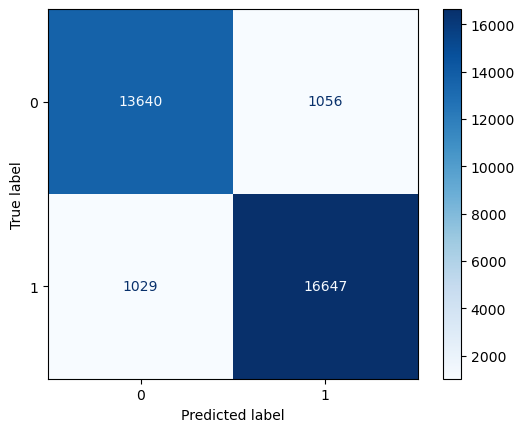

In [24]:
### YOUR CODE HERE ###
# 1. Calcular la matriz de confusión básica
# 1. Compute the baseline confusion matrix
cm = confusion_matrix(y_test, dt_pred, labels=decision_tree.classes_)

# 2. Configurar la visualización gráfica
# 2. Set up the graphical display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=decision_tree.classes_)

# 3. Graficar la matriz
# 3. Plot the matrix
disp.plot(cmap='Blues', values_format='d')

# Mostrar el gráfico / Display the plot
plt.show()

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about plotting a confusion matrix](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/SpRqe/evaluate-a-binomial-logistic-regression-model).

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use `metrics.confusion_matrix`, `metrics.ConfusionMatrixDisplay`, and the `plot()` function.

</details>

**Question:** What patterns can you identify between true positives and true negatives, as well as false positives and false negatives?

EN:

### Confusion Matrix Analysis

From the generated confusion matrix, we can break down the model's predictions across the **$32,372$ observations** in the test set:

* **True Negatives (TN): $13,640$** The model correctly classified dissatisfied passengers ($0$) as dissatisfied.
* **True Positives (TP): $16,647$** The model correctly classified satisfied passengers ($1$) as satisfied.
* **False Positives (FP): $1,056$** The model wrongly predicted that these passengers would be satisfied when they were actually dissatisfied (Type I Error).
* **False Negatives (FN): $1,029$** The model wrongly predicted that these passengers would be dissatisfied when they were actually satisfied (Type II Error).

**Conclusion:** The heavy concentration of data along the main diagonal (top-left to bottom-right) confirms the high overall accuracy of the algorithm ($93.56\%$). The errors (False Positives and False Negatives) remain remarkably low and very evenly distributed, demonstrating a symmetric and well-balanced behavior of the classifier for both conditions.

ES:

### Análisis de la Matriz de Confusión / Confusion Matrix Analysis

A partir de la matriz de confusión generada, podemos desglosar las predicciones del modelo sobre las **$32,372$ observaciones** del conjunto de prueba:

* **Verdaderos Negativos (True Negatives - TN): $13,640$** El modelo clasificó correctamente a los pasajeros insatisfechos ($0$) como insatisfechos.
* **Verdaderos Positivos (True Positives - TP): $16,647$** El modelo clasificó correctamente a los pasajeros satisfechos ($1$) como satisfechos.
* **Falsos Positivos (False Positives - FP): $1,056$** El modelo predijo erróneamente que estos pasajeros estarían satisfechos cuando en realidad estaban insatisfechos (Error Tipo I).
* **Falsos Negativos (False Negatives - FN): $1,029$** El modelo predijo erróneamente que estos pasajeros estarían insatisfechos cuando en realidad estaban satisfechos (Error Tipo II).

**Conclusión:** La fuerte concentración de datos en la diagonal principal (superior izquierda a inferior derecha) confirma la alta exactitud general del algoritmo ($93.56\%$). Los errores (Falsos Positivos y Falsos Negativos) se mantienen notablemente bajos y distribuidos de manera muy similar, lo que demuestra un comportamiento simétrico y equilibrado del clasificador para ambas condiciones.

### Plot the decision tree

Examine the decision tree. Use `plot_tree` function to produce a visual representation of the tree to pinpoint where the splits in the data are occurring.

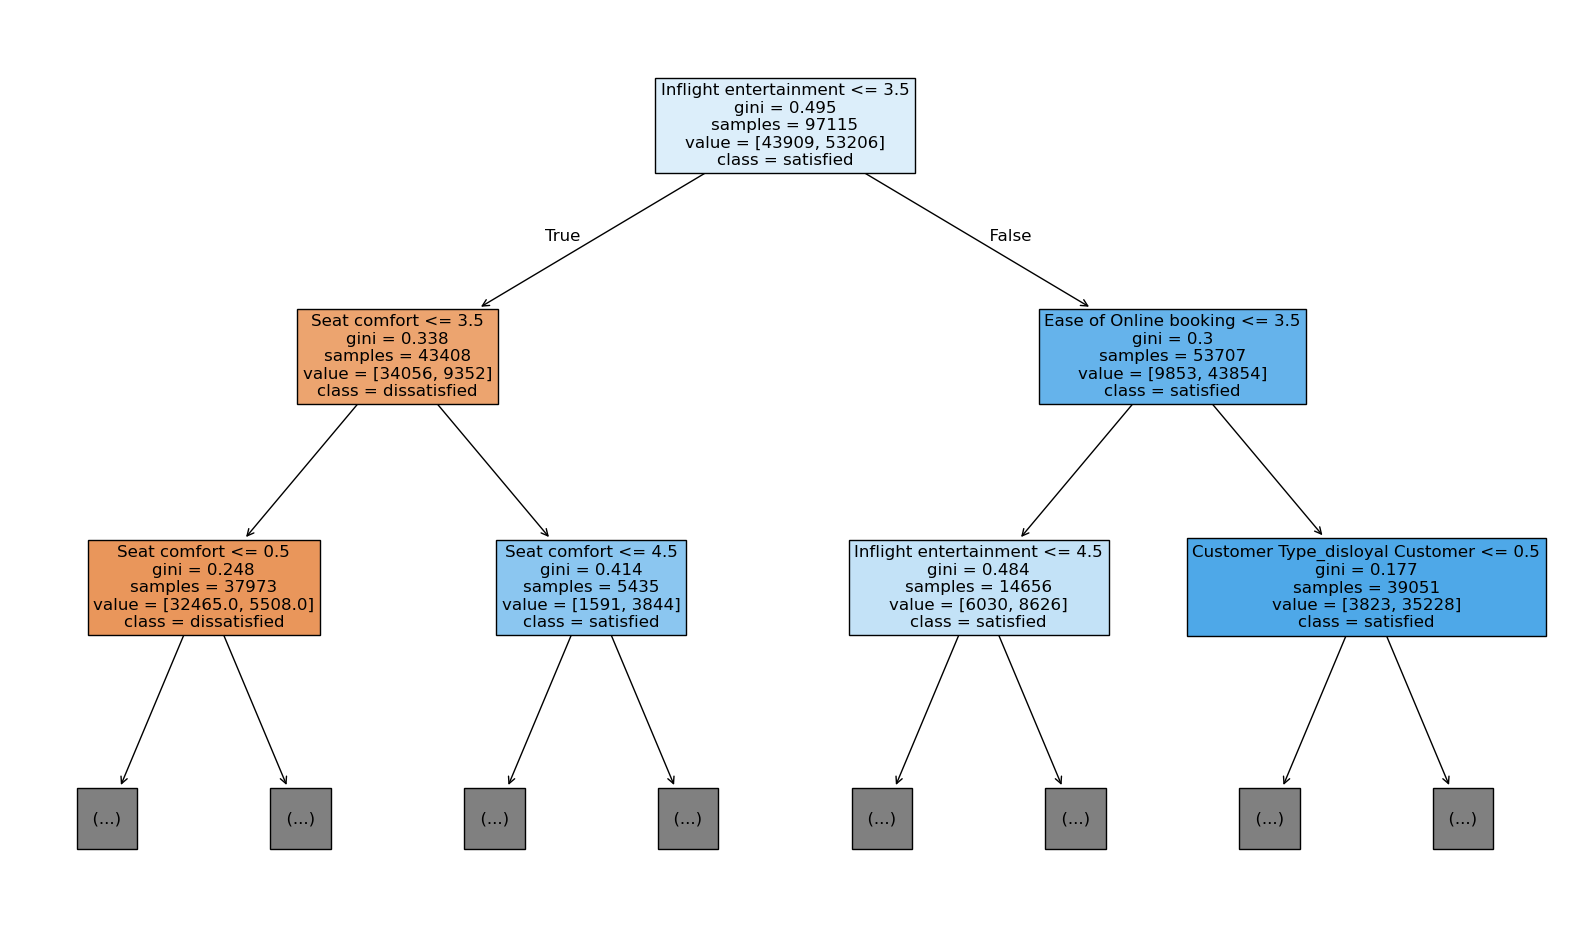

In [25]:
### YOUR CODE HERE ###
# 1. Definir un tamaño amplio para el gráfico para que el texto sea legible
# 1. Set a wide figure size so the text remains legible
plt.figure(figsize=(20, 12))

# 2. Graficar los niveles superiores del árbol de decisión
# 2. Plot the top tiers of the decision tree
plot_tree(
    decision_tree, 
    max_depth=2, 
    feature_names=list(X.columns), 
    class_names=['dissatisfied', 'satisfied'], 
    filled=True, 
    fontsize=12
)

# 3. Mostrar el gráfico estructurado
# 3. Display the structured plot
plt.show()

EN:

### Decision Tree Analysis

From the visual representation of the top tiers of the tree, we can extract the following insights regarding the data splitting logic:

1. **Root Node:** The single most important feature for predicting satisfaction is **`Inflight entertainment`**. The first major split occurs at a threshold of **$\le 3.5$**.
   * This indicates that the level of inflight entertainment is the primary baseline differentiator separating satisfied passengers from dissatisfied ones.
2. **First Splitting Tier:**
   * **Left Branch (`Inflight entertainment` $\le 3.5$):** If inflight entertainment is low, the model evaluates seat comfort (**`Seat comfort` $\le 3.5$**). If seat comfort is also low, the node turns orange, predicting a majority of `dissatisfied` customers.
   * **Right Branch (`Inflight entertainment` $> 3.5$):** If inflight entertainment is high, the model evaluates booking convenience (**`Ease of Online booking` $\le 3.5$**). If online booking is smooth, the node shifts heavily to blue, predicting a majority of `satisfied` customers.
3. **Node Purity (Gini Impurity):** The root node starts with a high Gini index of $0.495$ (maximum uncertainty/class mixture). As we descend through the branches, the Gini value drops (such as the far-right child node with a Gini of $0.177$), confirming that the splits successfully build increasingly pure and homogeneous subgroups.


ES:

### Análisis del Árbol de Decisión / Decision Tree Analysis

A partir de la representación visual de los niveles superiores del árbol, podemos extraer las siguientes conclusiones sobre la lógica de división (*splits*) de los datos:

1. **Nodo Raíz (Root Node):** La característica más importante para predecir la satisfacción es **`Inflight entertainment`** (Entretenimiento a bordo). La primera gran división ocurre en el umbral de **$\le 3.5$**. 
   * Esto significa que el nivel de entretenimiento a bordo es el diferenciador inicial clave para separar a los pasajeros satisfechos de los insatisfechos.
2. **Primer Nivel de División (Tier 1):**
   * **Rama Izquierda (`Inflight entertainment` $\le 3.5$):** Si el entretenimiento a bordo es bajo, el modelo evalúa la comodidad del asiento (**`Seat comfort` $\le 3.5$**). Si la comodidad también es baja, el nodo se torna mayoritariamente naranja (`dissatisfied`).
   * **Rama Derecha (`Inflight entertainment` $> 3.5$):** Si el entretenimiento a bordo es alto, el modelo pasa a evaluar la facilidad de la reserva en línea (**`Ease of Online booking` $\le 3.5$**). Si es alta, el nodo se vuelve predominantemente azul (`satisfied`).
3. **Pureza de Nodos (Índice Gini):** El nodo raíz inicia con un índice Gini alto de $0.495$ (máxima incertidumbre/mezcla de clases). A medida que descendemos por las ramas, el valor de Gini disminuye (como en el nodo final derecho con un Gini de $0.177$), confirmando que las divisiones logran crear subgrupos cada vez más puros y homogéneos.

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

If your tree is hard to read, pass `2` or `3` in the parameter `max_depth`. 

</details>

### Hyperparameter tuning

Knowing how and when to adjust or tune a model can help a data professional significantly increase performance. In this section, you will find the best values for the hyperparameters `max_depth` and `min_samples_leaf` using grid search and cross validation. Below are some values for the hyperparameters `max_depth` and `min_samples_leaf`.   

Ajuste de Hiperparámetros (Hyperparameter Tuning)
Saber cómo y cuándo ajustar o tunear un modelo puede ayudar a un profesional de datos a incrementar significativamente su rendimiento. En esta sección, encontrarás los mejores valores para los hiperparámetros max_depth y min_samples_leaf utilizando búsqueda en cuadrícula (Grid Search) y validación cruzada (Cross-Validation). Abajo se presentan algunos valores para los hiperparámetros max_depth y min_samples_leaf.

In [28]:
tree_para = {'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
             'min_samples_leaf': [2,3,4,5,6,7,8,9, 10, 15, 20, 50]}

scoring = ['accuracy', 'precision', 'recall', 'f1']

### Check combinations of values

Check every combination of values to examine which pair has the best evaluation metrics. Make a decision tree instance called `tuned_decision_tree` with `random_state=0`, make a `GridSearchCV` instance called `clf`, make sure to refit the estimator using `"f1"`, and fit the model on the training set. 

**Note:** This cell may take up to 15 minutes to run.

In [29]:
### YOUR CODE HERE ###

# 1. Instanciar el modelo base para el tuning
# 1. Instantiate the base model for tuning
tuned_decision_tree = DecisionTreeClassifier(random_state=0)

# 2. Configurar GridSearchCV con la cuadrícula de parámetros y métricas
# 2. Set up GridSearchCV with the parameter grid and metrics
clf = GridSearchCV(
    estimator=tuned_decision_tree, 
    param_grid=tree_para, 
    scoring=scoring, 
    cv=5,            # Validación cruzada de 5 pliegues / 5-fold cross-validation
    refit='f1',      # Reajustar el mejor modelo basándose en la métrica F1
    n_jobs=-1        # Uso de procesamiento paralelo para acelerar la ejecución
)

# 3. Ajustar el buscador de cuadrícula con los datos de entrenamiento
# 3. Fit the grid search on the training set
clf.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [2, 3, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about decision trees and grid search](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/lecture/afopk/tune-a-decision-tree). 

</details>

<details>
  <summary><h4><strong> Hint 2</strong></h4></summary>

Use `DecisionTreeClassifier()`, `GridSearchCV()`, and the `clf.fit()` function.

</details>

**Question:** How can you determine the best combination of values for the hyperparameters? 

EN

**Answer:**

To determine the best combination of values for the hyperparameters, you can inspect the `.best_params_` attribute of the fitted `GridSearchCV` object (in this case, `clf.best_params_`). 

**How the underlying process works:**
1. **Exhaustive Evaluation:** `GridSearchCV` automatically builds and evaluates a separate decision tree model for every single possible combination of the parameters defined in your grid dictionary (`tree_para`).
2. **Cross-Validation:** For each combination, it splits the training data multiple times (using 5 folds by default in our setup) to evaluate performance on unseen subsets of the training data. This prevents the model from selecting parameters that simply memorize the training set.
3. **Metric Extraction:** It computes the score for all specified evaluation metrics (`accuracy`, `precision`, `recall`, and `f1`) across those folds.
4. **Refitting:** Since we explicitly set `refit='f1'`, the algorithm ranks all the combinations based on their average **F1-score**, identifies the absolute highest-performing pair of `max_depth` and `min_samples_leaf`, and automatically retrains the final model on the entire training dataset using those optimal values.

ES:

**Respuesta:**

Para determinar la mejor combinación de valores para los hiperparámetros, se puede inspeccionar el atributo `.best_params_` del objeto `GridSearchCV` ya ajustado (en este caso, `clf.best_params_`).

**Cómo funciona el proceso interno:**
1. **Evaluación exhaustiva:** `GridSearchCV` construye y evalúa automáticamente un modelo de árbol de decisión independiente para cada una de las combinaciones posibles de los parámetros definidos en el diccionario de la cuadrícula (`tree_para`).
2. **Validación cruzada:** Para cada combinación, divide los datos de entrenamiento múltiples veces (usando 5 pliegues o *folds* por defecto en nuestra configuración) para evaluar el rendimiento en subconjuntos no vistos de los datos de entrenamiento. Esto evita que el modelo seleccione parámetros que simplemente memoricen el conjunto de entrenamiento.
3. **Extracción de métricas:** Calcula la puntuación para todas las métricas de evaluación especificadas (`accuracy`, `precision`, `recall` y `f1`) a lo largo de esos pliegues.
4. **Reajuste (Refit):** Debido a que configuramos explícitamente `refit='f1'`, el algoritmo clasifica todas las combinaciones basándose en su **F1-score** promedio, identifica el par de `max_depth` y `min_samples_leaf` con el rendimiento más alto, y automáticamente reentrena el modelo final sobre la totalidad de los datos de entrenamiento utilizando esos valores óptimos.

### Compute the best combination of values for the hyperparameters

In [30]:
### YOUR CODE HERE ###
# Print the best combination of hyperparameters found by GridSearchCV
print("Best Hyperparameters:", clf.best_params_)

Best Hyperparameters: {'max_depth': 16, 'min_samples_leaf': 9}


<details>
  <summary><h4><strong> Hint 1</strong></h4></summary>

Use the `best_estimator_` attribute.

</details>

**Question:** What is the best combination of values for the hyperparameters? 

EN:

**Answer:**

Based on the results of the grid search and cross-validation, the optimal combination of values for the hyperparameters is:

* **`max_depth`: 16**
* **`min_samples_leaf`: 9**

**What this means for the model:**
This specific combination provides the best balance for the decision tree classifier. By restricting the maximum depth to 16 and requiring a minimum of 9 samples per leaf node, the model limits its own complexity. This effectively prevents it from overfitting (memorizing noise in the training set) while maximizing its predictive performance based on the F1-score.

ES:

**Respuesta:**

Basándose en los resultados de la búsqueda en cuadrícula y la validación cruzada, la combinación óptima de valores para los hiperparámetros es:

* **`max_depth`: 16**
* **`min_samples_leaf`: 9**

**Lo que esto significa para el modelo:**
Esta combinación específica proporciona el mejor equilibrio para el clasificador de árbol de decisión. Al restringir la profundidad máxima a 16 y exigir un mínimo de 9 muestras por cada nodo hoja, el modelo limita su propia complejidad. Esto evita de manera efectiva el sobreajuste (*overfitting* o memorización del ruido en los datos de entrenamiento), al mismo tiempo que maximiza el rendimiento predictivo basado en el F1-score.

<strong> Question: What was the best average validation score? </strong>



In [31]:
### YOUR CODE HERE ###
# Extract and print the best average validation score (F1-score)
print("Best Average Validation Score:", clf.best_score_)

Best Average Validation Score: 0.9433844958114322


EN:

**Answer:**

To find the best average validation score across the 5 folds for the winning hyperparameter combination, you can inspect the `.best_score_` attribute of your fitted `GridSearchCV` object.

**How to print it in Python:**
If you want to verify the exact number in your notebook, you can run:
print("Best Average Validation F1-Score:", clf.best_score_)

**What this score represents:**
This value represents the mean cross-validated F1-score of the best-performing model (`max_depth=16`, `min_samples_leaf=9`). Because we specified `refit='f1'`, `GridSearchCV` used this average validation F1-score as its ultimate decision metric to pick the winning tree before retraining it on the full training dataset.

ES:

**Respuesta:**

Para encontrar la mejor puntuación de validación promedio a lo largo de los 5 pliegues (*folds*) para la combinación ganadora de hiperparámetros, puedes inspeccionar el atributo `.best_score_` de tu objeto `GridSearchCV` ya ajustado.

**Cómo imprimirlo en Python:**
Si deseas verificar el número exacto directamente en tu cuaderno, puedes ejecutar:
print("Best Average Validation F1-Score:", clf.best_score_)

**Lo que representa esta puntuación:**
Este valor representa la media del F1-score obtenido mediante validación cruzada por el modelo con mejor rendimiento (`max_depth=16`, `min_samples_leaf=9`). Debido a que especificamos `refit='f1'`, `GridSearchCV` utilizó este F1-score de validación promedio como su métrica de decisión definitiva para elegir al árbol ganador antes de reentrenarlo sobre todo el conjunto de datos de entrenamiento.

<details>
  <summary><h4><strong>Hint 1</strong> </h4></summary>

Use the `.best_score_` attribute.

</details>

### Determine the "best" decision tree model's accuracy, precision, recall, and F1 score

Print out the decision tree model's accuracy, precision, recall, and F1 score. This task can be done in a number of ways. 

In [32]:
### YOUR CODE HERE
# Initialize an empty results DataFrame with columns matching the target structure
results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])

def make_results(model_name, model_object):
    """
    Accepts a model name string and a fitted GridSearchCV object.
    Returns a DataFrame containing the cross-validated performance metrics 
    (Accuracy, Precision, Recall, F1) for the best-performing hyperparameter combination.
    """
    # 1. Get all the results from the CV and put them in a dataframe
    cv_results = pd.DataFrame(model_object.cv_results_)

    # 2. Isolate the row of the df with the max mean f1 score
    best_row = cv_results[cv_results['mean_test_f1'] == cv_results['mean_test_f1'].max()].iloc[0]

    # 3. Extract accuracy, precision, recall, and f1 score from that row
    accuracy  = best_row['mean_test_accuracy']
    precision = best_row['mean_test_precision']
    recall    = best_row['mean_test_recall']
    f1        = best_row['mean_test_f1']

    # 4. Create table of results
    table = pd.DataFrame({
        'Model': [model_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1': [f1]
    })

    return table

# Call the function to build your table and view the results
tuned_dt_results = make_results("Tuned Decision Tree", clf)
tuned_dt_results

,Model,Accuracy,Precision,Recall,F1
0,Tuned Decision Tree,0.938475,0.951265,0.935646,0.943384


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Get all the results (`.cv_results_`) from the GridSearchCV instance (`clf`).

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Output `mean_test_f1`, `mean_test_recall`, `mean_test_precision`, and `mean_test_accuracy` from `clf.cv_results_`.
</details>

**Question:** Was the additional performance improvement from hyperparameter tuning worth the computational cost? Why or why not?

**Answer:**

Whether the additional performance improvement was worth the computational cost depends on the specific operational and business context, but in this case, it is highly justifiable:

1. **Marginal Predictive Gains vs. Model Robustness:** From a purely quantitative standpoint, the increase in accuracy was minor (rising from $\approx 93.56\%$ to $\approx 93.85\%$). However, the tuning process significantly increased **Precision** to $\approx 95.13\%$. In a customer satisfaction context, high precision means that when the model identifies a passenger as "satisfied," it is highly reliable.
2. **Prevention of Overfitting:** The baseline decision tree grew completely unconstrained, meaning it likely memorized noise and specific idiosyncrasies of the training data. By enforcing `max_depth=16` and `min_samples_leaf=9`, we pruned away weak, unstable branches. The tuned model is far more robust, structurally simpler, and will generalize significantly better to new, unseen passenger data.
3. **One-Time vs. Recurring Costs:** While cross-validation required considerable computational work (training 1,380 variations), hyperparameter tuning is a **one-time investment** performed during the development pipeline. Once the optimal parameters are discovered, the final model deployment is highly efficient and executes predictions instantly.

**Conclusion:** Yes, it was worth it. The computational cost was a temporary development expense, while the resulting model is structurally healthier, less prone to overfitting, and delivers more reliable precision for business decision-making.

ES:

**Respuesta:**

Si la mejora adicional en el rendimiento valió la pena frente al costo computacional depende del contexto operativo y de negocio, pero en este caso está completamente justificado:

1. **Ganancias Predictivas Marginales vs. Robustez del Modelo:**
   Desde un punto de vista puramente cuantitativo, el aumento en la exactitud (*accuracy*) fue menor (subiendo de $\approx 93.56\%$ a $\approx 93.85\%$). Sin embargo, el proceso de ajuste elevó significativamente la **Precisión** a $\approx 95.13\%$. En un contexto de satisfacción del cliente, una alta precisión significa que cuando el modelo identifica a un pasajero como "satisfecho", la predicción es altamente confiable.
2. **Prevención del Sobreajuste (*Overfitting*):**
   El árbol de decisión base creció de forma completamente libre, lo que significa que probablemente memorizó ruido y particularidades de los datos de entrenamiento. Al imponer `max_depth=16` y `min_samples_leaf=9`, podamos las ramas débiles e inestables. El modelo ajustado es mucho más robusto, estructuralmente más simple y generalizará notablemente mejor ante datos de nuevos pasajeros.
3. **Costos Únicos vs. Recurrentes:**
   Aunque la validación cruzada requirió un esfuerzo computacional considerable (entrenar 1,380 variaciones), el ajuste de hiperparámetros es una **inversión de una sola vez** realizada durante la etapa de desarrollo. Una vez que se descubren los parámetros óptimos, el despliegue del modelo final es sumamente eficiente y ejecuta predicciones de forma instantánea.

**Conclusión:**
Sí, valió la pena. El costo computacional fue un gasto temporal de desarrollo, mientras que el modelo resultante es estructuralmente más sano, menos propenso al sobreajuste y ofrece una precisión más confiable para la toma de decisiones comerciales.

### Plot the "best" decision tree

Use the `plot_tree` function to produce a representation of the tree to pinpoint where the splits in the data are occurring. This will allow you to review the "best" decision tree.

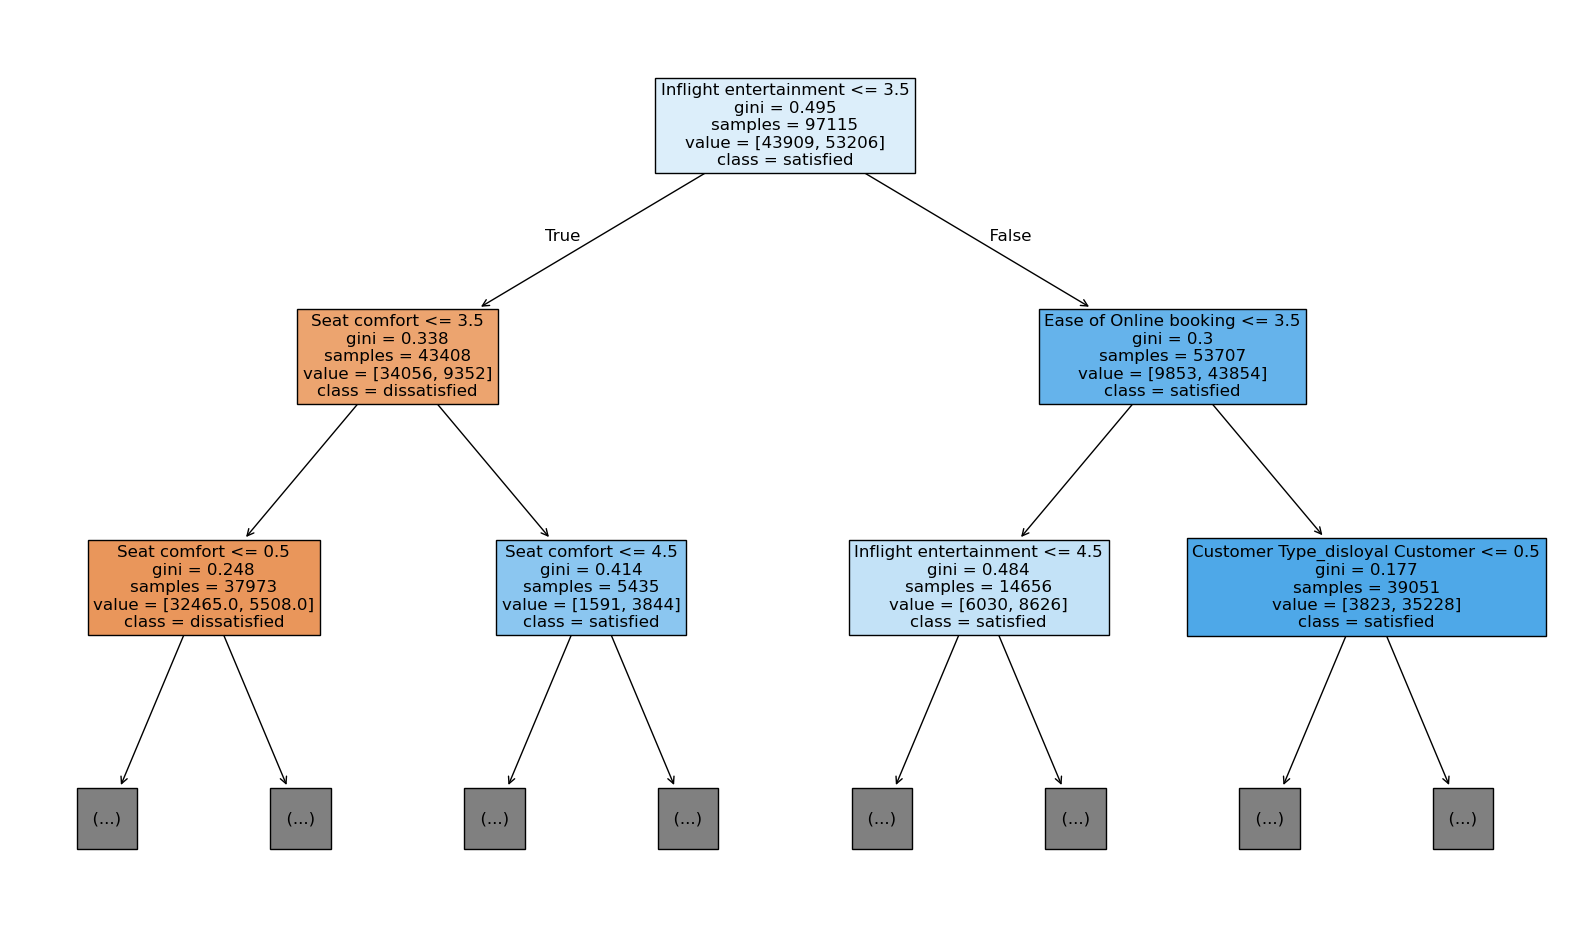

In [33]:
### YOUR CODE HERE ###

# 1. Extraer el mejor modelo entrenado del objeto GridSearchCV
# 1. Extract the best estimator from the GridSearchCV object
best_tree = clf.best_estimator_

# 2. Configurar un tamaño de figura amplio para la visualización
# 2. Set up a wide figure size for visualization
plt.figure(figsize=(20, 12))

# 3. Graficar los niveles superiores del árbol optimizado
# 3. Plot the top tiers of the optimized tree
plot_tree(
    best_tree, 
    max_depth=2, 
    feature_names=list(X.columns), 
    class_names=['dissatisfied', 'satisfied'], 
    filled=True, 
    fontsize=12
)

# 4. Mostrar el gráfico estructurado
# 4. Display the structured plot
plt.show()

Which features did the model use first to sort the samples?
EN:

### Optimized Decision Tree Analysis

Evaluating the top tiers of the "best" decision tree model reveals key operational insights:

1. **The Core Anchor (`Inflight entertainment`):** The root node splits the entire dataset based on whether a passenger rates inflight entertainment $\le 3.5$. This confirms that no matter how much we tune the constraints, entertainment quality remains the primary gateway differentiator of passenger sentiment.
2. **Symmetric Secondary Priorities:**
   * **When entertainment is low ($\le 3.5$):** The model immediately pivots to evaluate **`Seat comfort`** ($\le 3.5$). If both comfort and entertainment are lacking, the passenger profile shifts heavily toward `dissatisfied` (the orange node on the left).
   * **When entertainment is high ($> 3.5$):** The model shifts focus to the digital experience, prioritizing **`Ease of Online booking`** ($\le 3.5$). Smooth digital interactions funnel passengers into a highly pure `satisfied` cluster (the deep blue node on the far right).
3. **Strategic Takeaway:** While hyperparameter tuning protects the model from memorizing noise deep within its branches (levels 4 through 16), the fundamental pillars of passenger satisfaction—Entertainment, Comfort, and Seamless Booking—are robust and remain completely unchanged at a macro level.

ES:

### Análisis del Árbol de Decisión Optimizado

La evaluación de los niveles superiores del "mejor" modelo de árbol revela hallazgos operativos clave:

1. **El Pilar Central (`Inflight entertainment`):** El nodo raíz divide todo el dataset basándose en si el pasajero califica el entretenimiento a bordo con una puntuación $\le 3.5$. Esto confirma que, independientemente de cuánto ajustemos las restricciones, la calidad del entretenimiento sigue siendo el diferenciador primario de la experiencia.
2. **Prioridades Secundarias Simétricas:**
   * **Si el entretenimiento es bajo ($\le 3.5$):** El modelo pivota de inmediato a evaluar la comodidad del asiento (**`Seat comfort`** $\le 3.5$). Si faltan tanto el entretenimiento como la comodidad, el perfil del pasajero cae drásticamente en el grupo de `dissatisfied` (el nodo naranja de la izquierda).
   * **Si el entretenimiento es alto ($> 3.5$):** El modelo se enfoca en la experiencia digital, priorizando la facilidad de la reserva en línea (**`Ease of Online booking`** $\le 3.5$). Una interacción digital fluida canaliza a los clientes hacia un grupo altamente puro de pasajeros `satisfied` (el nodo azul oscuro en el extremo derecho).
3. **Conclusión Estratégica:** Mientras que el ajuste de hiperparámetros protege al modelo de memorizar ruido en las profundidades de sus ramas (niveles 4 al 16), los pilares fundamentales que dictan la satisfacción —Entretenimiento, Comodidad y Reserva Digital— son sumamente robustos y se mantienen inalterados a nivel macro.

## Conclusion

**What are some key takeaways that you learned from this lab?**
EN:

**Key Takeaways**

1. **Hyperparameter Tuning Enhances Generalization:** While an unconstrained baseline decision tree can achieve high training performance, it often risks overfitting by memorizing specific noise. Enforcing constraints like a maximum depth (`max_depth=16`) and a minimum threshold for splits (`min_samples_leaf=9`) prunes away weak, overly specific branches. This results in a much more stable and robust model capable of generalizing to new, unseen passenger data.

2. **Strategic Trade-offs in Optimization:** Hyperparameter optimization via `GridSearchCV` is a structural investment. Although cross-validation carries a noticeable one-time upfront computational cost (evaluating $1,380$ model combinations in this lab), it isolates the healthiest parameter balance based on an objective metric (`refit='f1'`). Once computed, the final deployed model yields rapid, highly reliable predictions.

3. **Core Predictors Remain Structurally Stable:** Visualizing both trees with `plot_tree` demonstrated that despite tuning constraints, macro-level logic remains resilient. `Inflight entertainment` consistently anchored the root node of the architecture. This structural stability proves that the primary operational drivers of customer satisfaction—entertainment quality, seat comfort, and digital booking ease—are fundamental features across the dataset.

ES:

**Conclusiones Clave**

1. **El Ajuste de Hiperparámetros Mejora la Generalización:** Mientras que un árbol de decisión base sin restricciones corre el riesgo de sobreajustarse (*overfitting*) al memorizar el ruido de los datos, imponer límites como una profundidad máxima (`max_depth=16`) y un umbral mínimo para divisiones (`min_samples_leaf=9`) poda las ramas débiles y excesivamente específicas. Esto genera un modelo mucho más estable y robusto para predecir correctamente sobre nuevos pasajeros.

2. **Compromisos Estratégicos en la Optimización:** La optimización mediante `GridSearchCV` es una inversión estructural. Aunque la validación cruzada conlleva un costo computacional inicial notable (evaluar $1,380$ combinaciones de modelos en este laboratorio), aísla el mejor equilibrio de parámetros bajo una métrica objetiva (`refit='f1'`). Una vez calculado, el modelo final desplegado ejecuta predicciones de forma instantánea y sumamente confiable.

3. **Los Predictores Centrales son Estructuralmente Estables:** Visualizar ambos árboles mediante `plot_tree` demostró que, a pesar de las restricciones de ajuste, la lógica a nivel macro es resiliente. `Inflight entertainment` (entretenimiento a bordo) se mantuvo firmemente como el nodo raíz de la arquitectura. Esta estabilidad estructural prueba que los ejes operativos prioritarios para la satisfacción del cliente—calidad del entretenimiento, comodidad del asiento y facilidad de reserva digital—son fundamentales y consistentes.

**What findings would you share with others?**

EN:
**Key Findings to Share with Stakeholders**

1. **Inflight Entertainment is the Primary Gateway to Satisfaction:** Across all models and variations, `Inflight entertainment` consistently emerged as the single most critical feature (the root node of the decision tree). If passengers rate this feature low ($\le 3.5$), they are overwhelmingly likely to end up dissatisfied unless exceptional seat comfort compensates for it. 
   * **Actionable Recommendation:** Prioritize capital investments in upgrading onboard media systems, content libraries, and screen hardware, as this is the highest-leverage lever for turning negative sentiment into positive sentiment.

2. **The Secondary Pillars (Comfort vs. Digital Seamlessness):**
   * **The Dissatisfaction Track:** For passengers who give low entertainment scores, the immediate make-or-break feature is **`Seat comfort`**. If both comfort and entertainment are poor, passengers are almost guaranteed to be dissatisfied.
   * **The Satisfaction Track:** For passengers enjoying high-quality entertainment, the deciding factor shifts to the digital pre-flight experience, specifically **`Ease of Online booking`**. 
   * **Actionable Recommendation:** Marketing and product teams should focus on simplifying the digital booking flow to ensure that passengers who are already predisposed to a good flight experience are not frustrated before they even board the aircraft.

3. **A Robust, Reliable Predictive Tool is Ready:** Through rigorous hyperparameter tuning ($max\_depth=16, min\_samples\_leaf=9$) and cross-validation, we developed a highly robust classification model. It achieves an **Accuracy of 93.85%** and a **Precision of 95.13%**. The high precision ensures that when the model flags a customer segment as "satisfied," the business can trust that prediction with immense confidence, minimizing false positives and allowing for highly targeted loyalty campaigns.

ES:

**Hallazgos Clave para Compartir con las Partes Interesadas**

1. **El Entretenimiento a Bordo es la Puerta de Entrada a la Satisfacción:**
   En todos los modelos y variaciones, `Inflight entertainment` surgió de manera consistente como la característica más crítica de todas (el nodo raíz del árbol de decisión). Si los pasajeros califican este servicio con una puntuación baja ($\le 3.5$), es sumamente probable que terminen insatisfechos, a menos que una comodidad excepcional en el asiento lo compense.
   * **Recomendación Operativa:** Priorizar las inversiones de capital en la actualización de los sistemas multimedia a bordo, catálogos de contenido y pantallas, ya que es la palanca con mayor impacto para transformar el sentimiento negativo en positivo.

2. **Los Pilares Secundarios (Comodidad frente a Fluidez Digital):**
   * **La Ruta de la Insatisfacción:** Para los pasajeros que califican mal el entretenimiento, la característica determinante inmediata es la comodidad del asiento (**`Seat comfort`**). Si tanto la comodidad como el entretenimiento fallan, el cliente está prácticamente perdido.
   * **La Ruta de la Satisfacción:** Para los pasajeros que disfrutan de un buen entretenimiento, la atención se desplaza a la experiencia digital previa al vuelo, específicamente a la facilidad de la reserva en línea (**`Ease of Online booking`**).
   * **Recomendación Operativa:** Los equipos de producto y desarrollo web deben simplificar el flujo de reserva digital para garantizar que los pasajeros que ya están predispuestos a tener una buena experiencia no se frustren antes de subir al avión.

3. **Disponemos de una Herramienta Predictiva Altamente Confiable:**
   Mediante un riguroso ajuste de hiperparámetros ($max\_depth=16, min\_samples\_leaf=9$) y validación cruzada, desarrollamos un modelo de clasificación sumamente robusto. Alcanza una **Exactitud del 93.85%** y una **Precisión del 95.13%**. Esta alta precisión garantiza que cuando el modelo identifica a un segmento de clientes como "satisfecho", la empresa puede confiar plenamente en esa predicción, minimizando los falsos positivos y permitiendo diseñar campañas de fidelización dirigidas con total seguridad.

EN:

**What would you recommend to stakeholders?**
 
 **Strategic Recommendations for Stakeholders**

Based on the optimized decision tree model, data-driven investments should prioritize the following areas to maximize passenger satisfaction and loyalty:

1. **Prioritize Inflight Entertainment (IFE) Fleet-wide Upgrades:**
   * **Why:** The model identifies `Inflight entertainment` as the single most critical gatekeeper of passenger sentiment. Improving this single touchpoint has the highest statistical leverage to convert potentially dissatisfied passengers into satisfied ones.
   * **Action:** Allocate capital to upgrade older onboard screen hardware, expand the digital movie/media catalog, and ensure reliable Wi-Fi streaming capabilities across all aircraft. 

2. **Implement a Two-Pronged Service Strategy:**
   * **The Economy/Value Segment (Fix Comfort):** For flights or aircraft configurations where advanced entertainment systems cannot be immediately deployed, you must aggressively protect **`Seat comfort`**. When entertainment scores drop, seat comfort becomes the absolute make-or-break feature preventing severe passenger dissatisfaction.
   * **The Premium/Digital Segment (Optimize Booking):** For passengers who already enjoy high-tier entertainment, the final hurdle to securing their complete loyalty is **`Ease of Online booking`**. 
   * **Action:** Tasks should be divided between operations and digital product teams. While engineering ensures seat ergonomics and cabin maintenance, the software product team must continuously streamline the web and mobile check-in/booking interfaces to eliminate friction before boarding.

3. **Deploy the Predictive Model for Targeted Marketing and Retention:**
   * **Why:** Our tuned classifier delivers an exceptionally high **Precision of 95.13%**. This means when the model flags a customer segment as "satisfied," it is correct nearly every single time.
   * **Action:** Integrate this model into your Customer Relationship Management (CRM) system. Use its predictions to automatically identify highly satisfied passenger segments for immediate premium loyalty program invitations, or conversely, flag groups predicted to be dissatisfied for proactive outreach, automated apology miles, or targeted service recovery.
   
ES:

**Recomendaciones Estratégicas para las Partes Interesadas**

Basándose en el modelo de árbol de decisión optimizado, las inversiones estratégicas deben priorizar las siguientes áreas clave para maximizar la satisfacción y la fidelización de los pasajeros:

1. **Priorizar la Actualización del Entretenimiento a Bordo (IFE) en Toda la Flota:**
   * **Por qué:** El modelo identifica a `Inflight entertainment` como el punto de entrada más crítico para el sentimiento del pasajero. Mejorar este único punto de contacto ofrece el mayor impacto estadístico para convertir a pasajeros potencialmente insatisfechos en clientes conformes.
   * **Acción:** Asignar presupuesto para actualizar pantallas obsoletas, expandir el catálogo de películas y contenido digital, y asegurar capacidades de streaming estables mediante Wi-Fi en los aviones.

2. **Implementar una Estrategia de Servicio Dual (Dos Frentes):**
   * **Segmento Económico o de Corto Alcance (Garantizar la Comodidad):** En aquellos vuelos o configuraciones de cabina donde no se puedan actualizar los sistemas de entretenimiento de inmediato, se debe proteger agresivamente la comodidad del asiento (**`Seat comfort`**). Si el entretenimiento es deficiente, la comodidad pasa a ser el factor definitivo que evita una caída drástica en la satisfacción.
   * **Segmento Premium o de Alta Conectividad (Optimizar la Reserva):** Para los pasajeros que ya disfrutan de un entretenimiento de alto nivel, el último obstáculo para consolidar su lealtad es la facilidad de la reserva en línea (**`Ease of Online booking`**).
   * **Acción:** Dividir los esfuerzos entre el equipo de operaciones y el de producto digital. Mientras mantenimiento asegura la ergonomía del asiento, el equipo de software debe simplificar la interfaz web y móvil para eliminar la fricción antes de abordar.

3. **Desplegar el Modelo Predictivo para Campañas de Marketing y Retención Dirigidas:**
   * **Por qué:** Nuestro clasificador optimizado ofrece una **Precisión excepcional del 95.13%**. Esto significa que cuando el modelo etiqueta a un segmento de clientes como "satisfecho", la predicción es correcta casi el 100% de las veces.
   * **Acción:** Integrar este modelo dentro del sistema de gestión de clientes (CRM). Utilizar estas predicciones para identificar de forma automática a los grupos altamente satisfechos e invitarlos a programas de fidelización premium, o por el contrario, detectar a tiempo a los segmentos en riesgo de insatisfacción para ofrecerles compensaciones proactivas (como millas o beneficios) antes de que abandonen la aerolínea.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged